# Yahoo 凸优单标的策略版

本 Notebook 基于 Yahoo Finance 的 yfinance 数据源，将当前组合版策略逻辑映射为单一标的版本。

这里的核心变化不是重新设计一套新策略，而是把原本用于多资产组合分配的信号生成与凸优化思想，单标的化为“是否持有”和“持有多少”的仓位控制问题。

数据来源说明：
- 单标的与批量样本历史行情：Yahoo Finance / yfinance
- 标普500成分股列表：GitHub CSV，失败时回退 Wikipedia

保留的核心思想：
- L1 趋势滤波
- alpha 与 alpha_accel 趋势诊断
- regime 过滤
- 单标的 time-series momentum 复合打分
- 使用凸优化求单资产目标仓位
- 输出净值、基准与仓位图

In [5]:
# 安装必要依赖（首次运行时取消注释）
# !pip install yfinance pandas numpy matplotlib python-dotenv httpx cvxpy lxml

In [6]:
import os
import datetime
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import cvxpy as cp
import httpx
import backtrader as bt
import yfinance as yf

_cn_font_path = '/System/Library/Fonts/Hiragino Sans GB.ttc'
if os.path.exists(_cn_font_path):
    fm.fontManager.addfont(_cn_font_path)
    _cn_font_name = fm.FontProperties(fname=_cn_font_path).get_name()
else:
    _cn_font_name = 'DejaVu Sans'

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['font.sans-serif'] = [_cn_font_name, 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SYMBOL = 'MSFT'
DATA_START = datetime.datetime(2025, 1, 1)
DATA_END = datetime.datetime(2026, 3, 12)
DEFAULT_WARMUP_TRADING_DAYS = 160
DEFAULT_WARMUP_CALENDAR_DAYS = DEFAULT_WARMUP_TRADING_DAYS * 2
FETCH_START = DATA_START - datetime.timedelta(days=DEFAULT_WARMUP_CALENDAR_DAYS)
STRICT_WARMUP = True
STRICT_END_DATE_COVERAGE = False

print(f'所有依赖加载完成 | 中文字体: {_cn_font_name}')
print('数据源: Yahoo Finance / yfinance')
print(f'标的: {SYMBOL}')
print(f'正式回测区间: {DATA_START.date()} ~ {DATA_END.date()}')
print(f'预热抓取起点: {FETCH_START.date()}')
print(f'严格预热模式: {STRICT_WARMUP}')
print(f'结束日严格覆盖校验: {STRICT_END_DATE_COVERAGE}')

所有依赖加载完成 | 中文字体: Hiragino Sans GB
数据源: Yahoo Finance / yfinance
标的: MSFT
正式回测区间: 2025-01-01 ~ 2026-03-12
预热抓取起点: 2024-02-16
严格预热模式: True
结束日严格覆盖校验: False


In [7]:
print('=== Yahoo Finance 数据接口初始化 ===')
print('使用 yfinance 下载日线 OHLCV 数据')

def fetch_daily_history(symbol, start_date=None, end_date=None):
    download_end = None
    if end_date is not None:
        download_end = pd.Timestamp(end_date) + pd.Timedelta(days=1)

    df = yf.download(
        symbol,
        start=start_date,
        end=download_end,
        interval='1d',
        auto_adjust=False,
        actions=False,
        progress=False,
        threads=False
    )

    if df is None or df.empty:
        raise ValueError(f'未获取到 {symbol} 的 Yahoo 历史数据，请检查代码是否有效或数据源状态')

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    rename_map = {
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Adj Close': 'adj_close',
        'Volume': 'volume'
    }
    df = df.rename(columns=rename_map)

    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f'{symbol} Yahoo 数据缺少必要列: {missing_cols}')

    df.index = pd.to_datetime(df.index)
    if getattr(df.index, 'tz', None) is not None:
        df.index = df.index.tz_localize(None)

    df.index.name = 'datetime'
    df = df[required_cols].sort_index()
    df = df[~df.index.duplicated(keep='last')]
    df = df[(df['close'] > 0) & (df['volume'] >= 0)]

    if df.empty:
        raise ValueError(f'{symbol} Yahoo 历史数据清洗后为空，请检查数据有效性')

    return df

def validate_formal_coverage(formal_history, requested_end, strict=False, label='正式回测区间'):
    if formal_history.empty:
        raise ValueError(f'{label}为空，无法校验结束日覆盖情况')

    actual_last_date = pd.Timestamp(formal_history.index[-1]).date()
    requested_end_date = pd.Timestamp(requested_end).date()
    coverage_ok = actual_last_date >= requested_end_date

    if coverage_ok:
        msg = f'{label}结束日覆盖校验通过: 实际最后日期 {actual_last_date}，请求结束日期 {requested_end_date}'
    else:
        msg = (
            f'{label}结束日覆盖不足: 实际最后日期 {actual_last_date}，早于请求结束日期 {requested_end_date}。'
            '可能原因是请求日尚未收盘、交易日未结束、节假日或数据源延迟。'
        )
        if strict:
            raise ValueError(msg)

    return coverage_ok, msg, actual_last_date

def ensure_history_with_warmup(symbol, required_warmup_bars, strict=True):
    local_fetch_start = FETCH_START
    history = fetch_daily_history(symbol, start_date=local_fetch_start, end_date=DATA_END)
    available_bars = int((history.index < pd.Timestamp(DATA_START)).sum())

    expansion_round = 0
    while available_bars < required_warmup_bars and expansion_round < 4:
        expansion_round += 1
        expanded_calendar_days = max(
            DEFAULT_WARMUP_CALENDAR_DAYS * (expansion_round + 1),
            required_warmup_bars * (3 + expansion_round)
        )
        local_fetch_start = DATA_START - datetime.timedelta(days=expanded_calendar_days)
        history = fetch_daily_history(symbol, start_date=local_fetch_start, end_date=DATA_END)
        available_bars = int((history.index < pd.Timestamp(DATA_START)).sum())

    formal_mask = (history.index >= pd.Timestamp(DATA_START)) & (history.index <= pd.Timestamp(DATA_END))
    formal_history = history.loc[formal_mask]
    if formal_history.empty:
        raise ValueError('正式回测区间为空，请检查日期设置')

    if available_bars < required_warmup_bars:
        msg = (
            f'预热样本仍不足: 当前 {available_bars} 条，要求 {required_warmup_bars} 条。'
            f'已向前扩展到 {local_fetch_start.date()}，请检查标的上市时间或放宽窗口参数。'
        )
        if strict:
            raise ValueError(msg)
        warnings.warn(msg)

    return history, local_fetch_start, available_bars

=== Yahoo Finance 数据接口初始化 ===
使用 yfinance 下载日线 OHLCV 数据


In [8]:
TREND_WINDOW = 80
TREND_LAMBDA = 20.0
VOL_WINDOW = 20
SIGNAL_SPAN = 5
RISK_AVERSION = 12.0
TURNOVER_PENALTY = 0.003
MAX_WEIGHT = 1.0
INITIAL_CASH = 100000.0
COMMISSION_RATE = 0.0000
SLIPPAGE_PCT = 0.0000

V2_CONSERVATIVE_MIN_WEIGHT = 0.45
V2_ACCEL_WEIGHT = 0.35
V2_ADVANCED_UPTREND_MIN_WEIGHT = 0.55
V2_ADVANCED_RANGE_MAX_WEIGHT = 0.35
V2_ADVANCED_ALPHA_DEADZONE = 0.04
V2_ADVANCED_ALPHA_SCALE = 5.00
V2_ADVANCED_DEFAULT_RISK_MULTIPLIER = 0.65
V2_ADVANCED_DEFAULT_BEAR_PENALTY_MULTIPLIER = 1.00
V2_STATE_FIT_PENALTY = 0.08
V2_STATE_GAP_SCALE = 0.08

def l1_trend_filter(prices, lam=20.0):
    y = np.asarray(prices, dtype=float)
    n = len(y)
    if n < 3:
        return y.copy()

    x = cp.Variable(n)
    d2 = np.diff(np.eye(n), 2, axis=0)
    objective = cp.Minimize(0.5 * cp.sum_squares(y - x) + lam * cp.norm1(d2 @ x))
    problem = cp.Problem(objective)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        problem.solve(solver=cp.SCS, warm_start=True, verbose=False)

    if x.value is None:
        raise RuntimeError('L1 趋势滤波求解失败')

    return np.asarray(x.value).ravel()

def solve_long_only_weight(alpha, sigma, previous_weight, risk_aversion=12.0, turnover_penalty=0.003, max_weight=1.0):
    sigma = max(float(sigma), 1e-4)
    w = cp.Variable()
    objective = cp.Minimize(
        0.5 * risk_aversion * (sigma ** 2) * cp.square(w)
        - alpha * w
        + turnover_penalty * cp.abs(w - previous_weight)
    )
    constraints = [w >= 0.0, w <= max_weight]
    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        problem.solve(solver=cp.SCS, warm_start=True, verbose=False)

    if w.value is None:
        return float(previous_weight)
    return float(np.clip(w.value, 0.0, max_weight))

def infer_convex_state_weights(alpha, alpha_accel, trend_gap):
    target = np.array(
        [
            float(np.clip(alpha, -1.0, 1.0)),
            float(np.clip(alpha_accel, -1.0, 1.0)),
            float(np.clip(trend_gap / V2_STATE_GAP_SCALE, -1.0, 1.0)),
        ],
        dtype=float,
    )
    state_profiles = np.array(
        [
            [0.90, 0.05, -0.90],
            [0.25, 0.00, -0.25],
            [0.80, 0.00, -0.80],
        ],
        dtype=float,
    )
    prior = np.array([0.34, 0.33, 0.33], dtype=float)
    state_weights = cp.Variable(3)
    objective = cp.Minimize(
        cp.sum_squares(state_profiles @ state_weights - target)
        + V2_STATE_FIT_PENALTY * cp.sum_squares(state_weights - prior)
    )
    constraints = [state_weights >= 0.0, cp.sum(state_weights) == 1.0]
    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        problem.solve(solver=cp.SCS, warm_start=True, verbose=False)

    if state_weights.value is None:
        weights = prior.copy()
    else:
        weights = np.clip(np.asarray(state_weights.value).ravel(), 0.0, 1.0)
        weights = weights / (weights.sum() + 1e-8)

    bull_score, range_score, bear_score = weights.tolist()
    return {
        'bull_score': float(bull_score),
        'range_score': float(range_score),
        'bear_score': float(bear_score),
        'state_signal': float(bull_score - bear_score),
    }

def compute_convex_diagnostics(window_close, lam=20.0, signal_span=5):
    prices = np.asarray(window_close, dtype=float)
    log_price = np.log(prices)
    trend_log = l1_trend_filter(log_price, lam=lam)
    trend_price = np.exp(trend_log)

    span = int(min(signal_span, len(trend_log) - 1))
    if span < 1:
        alpha = 0.0
        alpha_accel = 0.0
        recent_slope = 0.0
        previous_slope = 0.0
    else:
        recent_slope = (trend_log[-1] - trend_log[-1 - span]) / span
        if len(trend_log) >= 2 * span + 1:
            previous_slope = (trend_log[-1 - span] - trend_log[-1 - 2 * span]) / span
        else:
            previous_slope = recent_slope
        hist_vol = np.std(np.diff(log_price)) + 1e-6
        alpha = np.tanh(recent_slope / hist_vol)
        alpha_accel = np.tanh((recent_slope - previous_slope) / hist_vol)

    trend_last = float(trend_price[-1])
    trend_gap = prices[-1] / trend_last - 1.0 if trend_last > 0 else 0.0
    state_info = infer_convex_state_weights(alpha, alpha_accel, trend_gap)

    return {
        'alpha': float(alpha),
        'alpha_accel': float(alpha_accel),
        'trend_last': trend_last,
        'trend_gap': float(trend_gap),
        'trend_series': trend_price,
        'recent_slope': float(recent_slope),
        'previous_slope': float(previous_slope),
        **state_info,
    }

def solve_single_asset_weight_v2(alpha, alpha_accel, trend_gap, sigma, previous_weight, bull_score, range_score, bear_score, profile='advanced'):
    sigma = max(float(sigma), 1e-4)

    raw_composite_alpha = alpha + V2_ACCEL_WEIGHT * alpha_accel + 0.55 * (bull_score - bear_score) - 0.25 * max(-trend_gap, 0.0)
    composite_alpha = V2_ADVANCED_ALPHA_SCALE * raw_composite_alpha
    composite_alpha = 0.0 if abs(composite_alpha) < V2_ADVANCED_ALPHA_DEADZONE else composite_alpha
    risk_aversion = RISK_AVERSION * (0.55 + 0.65 * range_score + 1.35 * bear_score) * V2_ADVANCED_DEFAULT_RISK_MULTIPLIER
    turnover_penalty = TURNOVER_PENALTY * (0.80 + 0.45 * range_score + 0.20 * bear_score)
    bear_penalty_multiplier = V2_ADVANCED_DEFAULT_BEAR_PENALTY_MULTIPLIER
    floor_cap = V2_ADVANCED_UPTREND_MIN_WEIGHT
    desired_floor = floor_cap * np.clip(
        0.65 * max(composite_alpha, 0.0) + 0.55 * bull_score - 0.60 * bear_score,
        0.0,
        1.0,
    )
    max_weight_cap = float(np.clip(
        MAX_WEIGHT - (MAX_WEIGHT - V2_ADVANCED_RANGE_MAX_WEIGHT) * range_score - 0.75 * bear_score,
        0.05,
        MAX_WEIGHT,
    ))

    target_weight = cp.Variable()
    floor_weight = cp.Variable()
    objective = cp.Minimize(
        0.5 * risk_aversion * (sigma ** 2) * cp.square(target_weight)
        - composite_alpha * target_weight
        + turnover_penalty * cp.abs(target_weight - previous_weight)
        + 3.5 * cp.square(floor_weight - desired_floor)
        + 2.5 * cp.square(target_weight - floor_weight)
        + (0.50 * bear_penalty_multiplier) * bear_score * target_weight
    )
    constraints = [
        target_weight >= 0.0,
        target_weight <= max_weight_cap,
        floor_weight >= 0.0,
        floor_weight <= floor_cap,
        floor_weight <= target_weight,
    ]
    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        problem.solve(solver=cp.SCS, warm_start=True, verbose=False)

    if target_weight.value is None or floor_weight.value is None:
        resolved_weight = float(np.clip(previous_weight, 0.0, max_weight_cap))
        resolved_floor = float(min(desired_floor, resolved_weight))
    else:
        resolved_weight = float(np.clip(target_weight.value, 0.0, max_weight_cap))
        resolved_floor = float(np.clip(floor_weight.value, 0.0, min(floor_cap, resolved_weight)))

    return {
        'target_weight': resolved_weight,
        'floor_weight': resolved_floor,
        'desired_floor': float(desired_floor),
        'composite_alpha': float(composite_alpha),
        'raw_composite_alpha': float(raw_composite_alpha),
        'max_weight_cap': float(max_weight_cap),
    }

def calc_performance_metrics(portfolio_value, benchmark_curve, strategy_label, benchmark_label):
    strategy_df = pd.DataFrame(index=portfolio_value.index)
    strategy_df['portfolio_value'] = portfolio_value.astype(float)
    strategy_df['portfolio_return'] = strategy_df['portfolio_value'].pct_change().fillna(0.0)
    base_value = float(strategy_df['portfolio_value'].iloc[0])
    strategy_df['equity_curve'] = strategy_df['portfolio_value'] / base_value
    strategy_df['benchmark_curve'] = benchmark_curve.reindex(strategy_df.index).ffill()

    trading_days = max(len(strategy_df), 1)
    total_return = strategy_df['equity_curve'].iloc[-1] - 1.0
    ann_return = (1.0 + total_return) ** (252.0 / trading_days) - 1.0 if trading_days > 1 else total_return
    ann_vol = strategy_df['portfolio_return'].std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    max_drawdown = (strategy_df['equity_curve'] / strategy_df['equity_curve'].cummax() - 1.0).min()

    bench_returns = strategy_df['benchmark_curve'].pct_change().fillna(0.0)
    bench_total_return = strategy_df['benchmark_curve'].iloc[-1] - 1.0
    bench_ann_return = (1.0 + bench_total_return) ** (252.0 / trading_days) - 1.0 if trading_days > 1 else bench_total_return
    bench_ann_vol = bench_returns.std() * np.sqrt(252)
    bench_sharpe = bench_ann_return / bench_ann_vol if bench_ann_vol > 0 else np.nan
    bench_drawdown = (strategy_df['benchmark_curve'] / strategy_df['benchmark_curve'].cummax() - 1.0).min()

    comparison = pd.DataFrame(
        {
            '总收益': [total_return, bench_total_return],
            '年化收益': [ann_return, bench_ann_return],
            '年化波动': [ann_vol, bench_ann_vol],
            'Sharpe': [sharpe, bench_sharpe],
            '最大回撤': [max_drawdown, bench_drawdown],
        },
        index=[strategy_label, benchmark_label],
    )
    return strategy_df, comparison

def wilders_average(series, length):
    values = pd.Series(series, dtype=float).reset_index(drop=True)
    result = pd.Series(np.nan, index=values.index, dtype=float)
    if len(values) < length:
        return result

    first_avg = values.iloc[:length].mean()
    result.iloc[length - 1] = first_avg
    alpha = 1.0 / length
    for idx in range(length, len(values)):
        result.iloc[idx] = alpha * values.iloc[idx] + (1.0 - alpha) * result.iloc[idx - 1]
    return result

def inertia(series, length):
    values = pd.Series(series, dtype=float).reset_index(drop=True)
    result = pd.Series(np.nan, index=values.index, dtype=float)
    if len(values) < length:
        return result

    x = np.arange(1, length + 1, dtype=float)
    x_mean = x.mean()
    denom = np.sum((x - x_mean) ** 2)
    for idx in range(length - 1, len(values)):
        window = values.iloc[idx - length + 1: idx + 1]
        if window.isna().any():
            continue
        y = window.to_numpy(dtype=float)
        y_mean = y.mean()
        slope = np.sum((x - x_mean) * (y - y_mean)) / denom
        intercept = y_mean - slope * x_mean
        result.iloc[idx] = slope * x[-1] + intercept
    return result

def compute_tos_adx(ohlc_df, length=14):
    high = pd.Series(ohlc_df['high'], dtype=float).reset_index(drop=True)
    low = pd.Series(ohlc_df['low'], dtype=float).reset_index(drop=True)
    close = pd.Series(ohlc_df['close'], dtype=float).reset_index(drop=True)
    prev_close = close.shift(1).fillna(close)

    tr_raw = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    tr1 = wilders_average(tr_raw, length)

    hd = high - high.shift(1)
    ld = low.shift(1) - low
    dmp_raw = pd.Series(np.where((hd > 0) & (hd > ld), hd, 0.0), dtype=float)
    dmm_raw = pd.Series(np.where((ld > 0) & (ld > hd), ld, 0.0), dtype=float)

    dmp = wilders_average(dmp_raw, length)
    dmm = wilders_average(dmm_raw, length)

    pdi = (dmp * 100.0 / tr1).replace([np.inf, -np.inf], np.nan)
    mdi = (dmm * 100.0 / tr1).replace([np.inf, -np.inf], np.nan)
    pdi2 = inertia(pdi, 7)
    mdi2 = inertia(mdi, 7)

    denom = (mdi + pdi).replace(0.0, np.nan)
    dx = ((mdi - pdi).abs() / denom) * 100.0
    adx = wilders_average(dx, length)
    adx2 = inertia(adx, 7)

    buy_signal = pd.Series(
        np.where(
            (adx > 10)
            & (adx.shift(1) <= 10)
            & (pdi > mdi)
            & ((pdi - mdi) > (pdi.shift(1) - mdi.shift(1))),
            adx,
            np.nan,
        ),
        dtype=float,
    )

    result = pd.DataFrame({
        'PDI': pdi,
        'PDI2': pdi2,
        'MDI': mdi,
        'MDI2': mdi2,
        'ADX': adx,
        'ADX2': adx2,
        'BuySignal': buy_signal,
        'Line10': 10.0,
        'Line20': 20.0,
        'Line40': 40.0,
    })
    result.index = ohlc_df.index
    return result

print('单标的 V2 Advanced 新优化核心函数已加载')
print(f'TREND_WINDOW={TREND_WINDOW}, TREND_LAMBDA={TREND_LAMBDA}, VOL_WINDOW={VOL_WINDOW}')
print(f'RISK_AVERSION={RISK_AVERSION}, TURNOVER_PENALTY={TURNOVER_PENALTY}, MAX_WEIGHT={MAX_WEIGHT}')
print(f'INITIAL_CASH={INITIAL_CASH:,.0f}, COMMISSION_RATE={COMMISSION_RATE:.4%}, SLIPPAGE_PCT={SLIPPAGE_PCT:.4%}')
print(f'进阶版默认参数: risk_multiplier={V2_ADVANCED_DEFAULT_RISK_MULTIPLIER:.2f} | alpha_scale={V2_ADVANCED_ALPHA_SCALE:.2f} | bear_penalty_multiplier={V2_ADVANCED_DEFAULT_BEAR_PENALTY_MULTIPLIER:.2f}')
print(f'进阶版凸优化仓位底线上限: {V2_ADVANCED_UPTREND_MIN_WEIGHT:.0%} | 震荡压缩上限参考: {V2_ADVANCED_RANGE_MAX_WEIGHT:.0%}')
print('已加入 thinkScript ADX 转 Python 计算函数')

单标的 V2 Advanced 新优化核心函数已加载
TREND_WINDOW=80, TREND_LAMBDA=20.0, VOL_WINDOW=20
RISK_AVERSION=12.0, TURNOVER_PENALTY=0.003, MAX_WEIGHT=1.0
INITIAL_CASH=100,000, COMMISSION_RATE=0.0000%, SLIPPAGE_PCT=0.0000%
进阶版默认参数: risk_multiplier=0.65 | alpha_scale=5.00 | bear_penalty_multiplier=1.00
进阶版凸优化仓位底线上限: 55% | 震荡压缩上限参考: 35%
已加入 thinkScript ADX 转 Python 计算函数


=== Yahoo V2 Advanced 单标的结果 ===
当前标的: MSFT | 预热样本数: 220 | 起点: 2024-02-16
正式回测区间: 2025-01-02 ~ 2026-03-12
结束日覆盖状态: V2 Advanced 正式回测区间结束日覆盖校验通过: 实际最后日期 2026-03-12，请求结束日期 2026-03-12


,总收益,年化收益,年化波动,Sharpe,最大回撤
V2 Advanced,6.26%,5.27%,5.80%,0.91,-5.20%
Buy & Hold,-3.99%,-3.39%,26.30%,-0.13,-29.07%


,close,ema60,trend,alpha,alpha_accel,bull_score,range_score,bear_score,state_signal,raw_composite_alpha,composite_alpha,max_weight_cap,floor_weight,target_weight,actual_weight,ADX,PDI2,MDI2,equity_curve,buy_hold_curve
datetime,,,,,,,,,,,,,,,,,,,,
2026-02-25,400.600006,445.484961,409.868201,-0.164754,-1.962649e-13,0.200390,0.348222,0.451388,-0.250998,-0.308457,-1.542283,0.435115,4.669723e-10,4.669723e-10,0.0,36.296337,18.400164,39.132556,1.062627,0.957045
2026-02-26,401.720001,444.050045,408.229483,-0.165885,-2.059978e-13,0.229852,0.332054,0.438094,-0.208242,-0.284404,-1.422021,0.455594,3.018606e-10,3.018606e-10,0.0,35.009355,21.427425,37.676576,1.062627,0.959721
2026-02-27,392.739990,442.367748,406.092962,-0.167152,-2.047015e-13,0.154230,0.372309,0.473461,-0.319231,-0.350950,-1.754750,0.402903,0.000000e+00,0.000000e+00,0.0,34.364426,22.974029,37.834303,1.062627,0.938267
2026-03-02,398.549988,440.931100,404.347108,-0.167596,-2.220669e-13,0.236690,0.327869,0.435441,-0.198750,-0.280493,-1.402463,0.460305,1.164327e-11,1.164327e-11,0.0,33.336573,24.701072,36.369750,1.062627,0.952148
2026-03-03,403.929993,439.717949,402.918127,-0.167837,-1.937833e-13,0.311638,0.287527,0.400835,-0.089197,-0.216896,-1.084479,0.512481,0.000000e+00,0.000000e+00,0.0,31.861124,26.288755,33.580512,1.062627,0.965001
2026-03-04,405.200012,438.586213,401.504962,-0.169496,-1.854091e-13,0.341111,0.271195,0.387694,-0.046583,-0.195116,-0.975582,0.532953,2.341624e-11,2.341624e-11,0.0,30.097208,27.083356,31.527809,1.062627,0.968035
2026-03-05,410.679993,437.671255,400.243286,-0.169755,-1.661354e-13,0.416165,0.230791,0.353045,0.063120,-0.135039,-0.675195,0.585203,0.000000e+00,0.000000e+00,0.0,28.405632,26.143798,29.721508,1.062627,0.981127
2026-03-06,408.959991,436.729902,398.968331,-0.171974,-1.859949e-13,0.411153,0.232821,0.356026,0.055126,-0.141655,-0.708273,0.581647,8.515636e-13,3.230417e-11,0.0,26.695046,26.080535,27.839095,1.062627,0.977018
2026-03-09,409.410004,435.834168,397.972695,-0.171927,-1.582270e-13,0.427609,0.223993,0.348398,0.079211,-0.128361,-0.641804,0.593106,7.747165e-12,3.892028e-11,0.0,25.546718,25.812006,27.391028,1.062627,0.978093


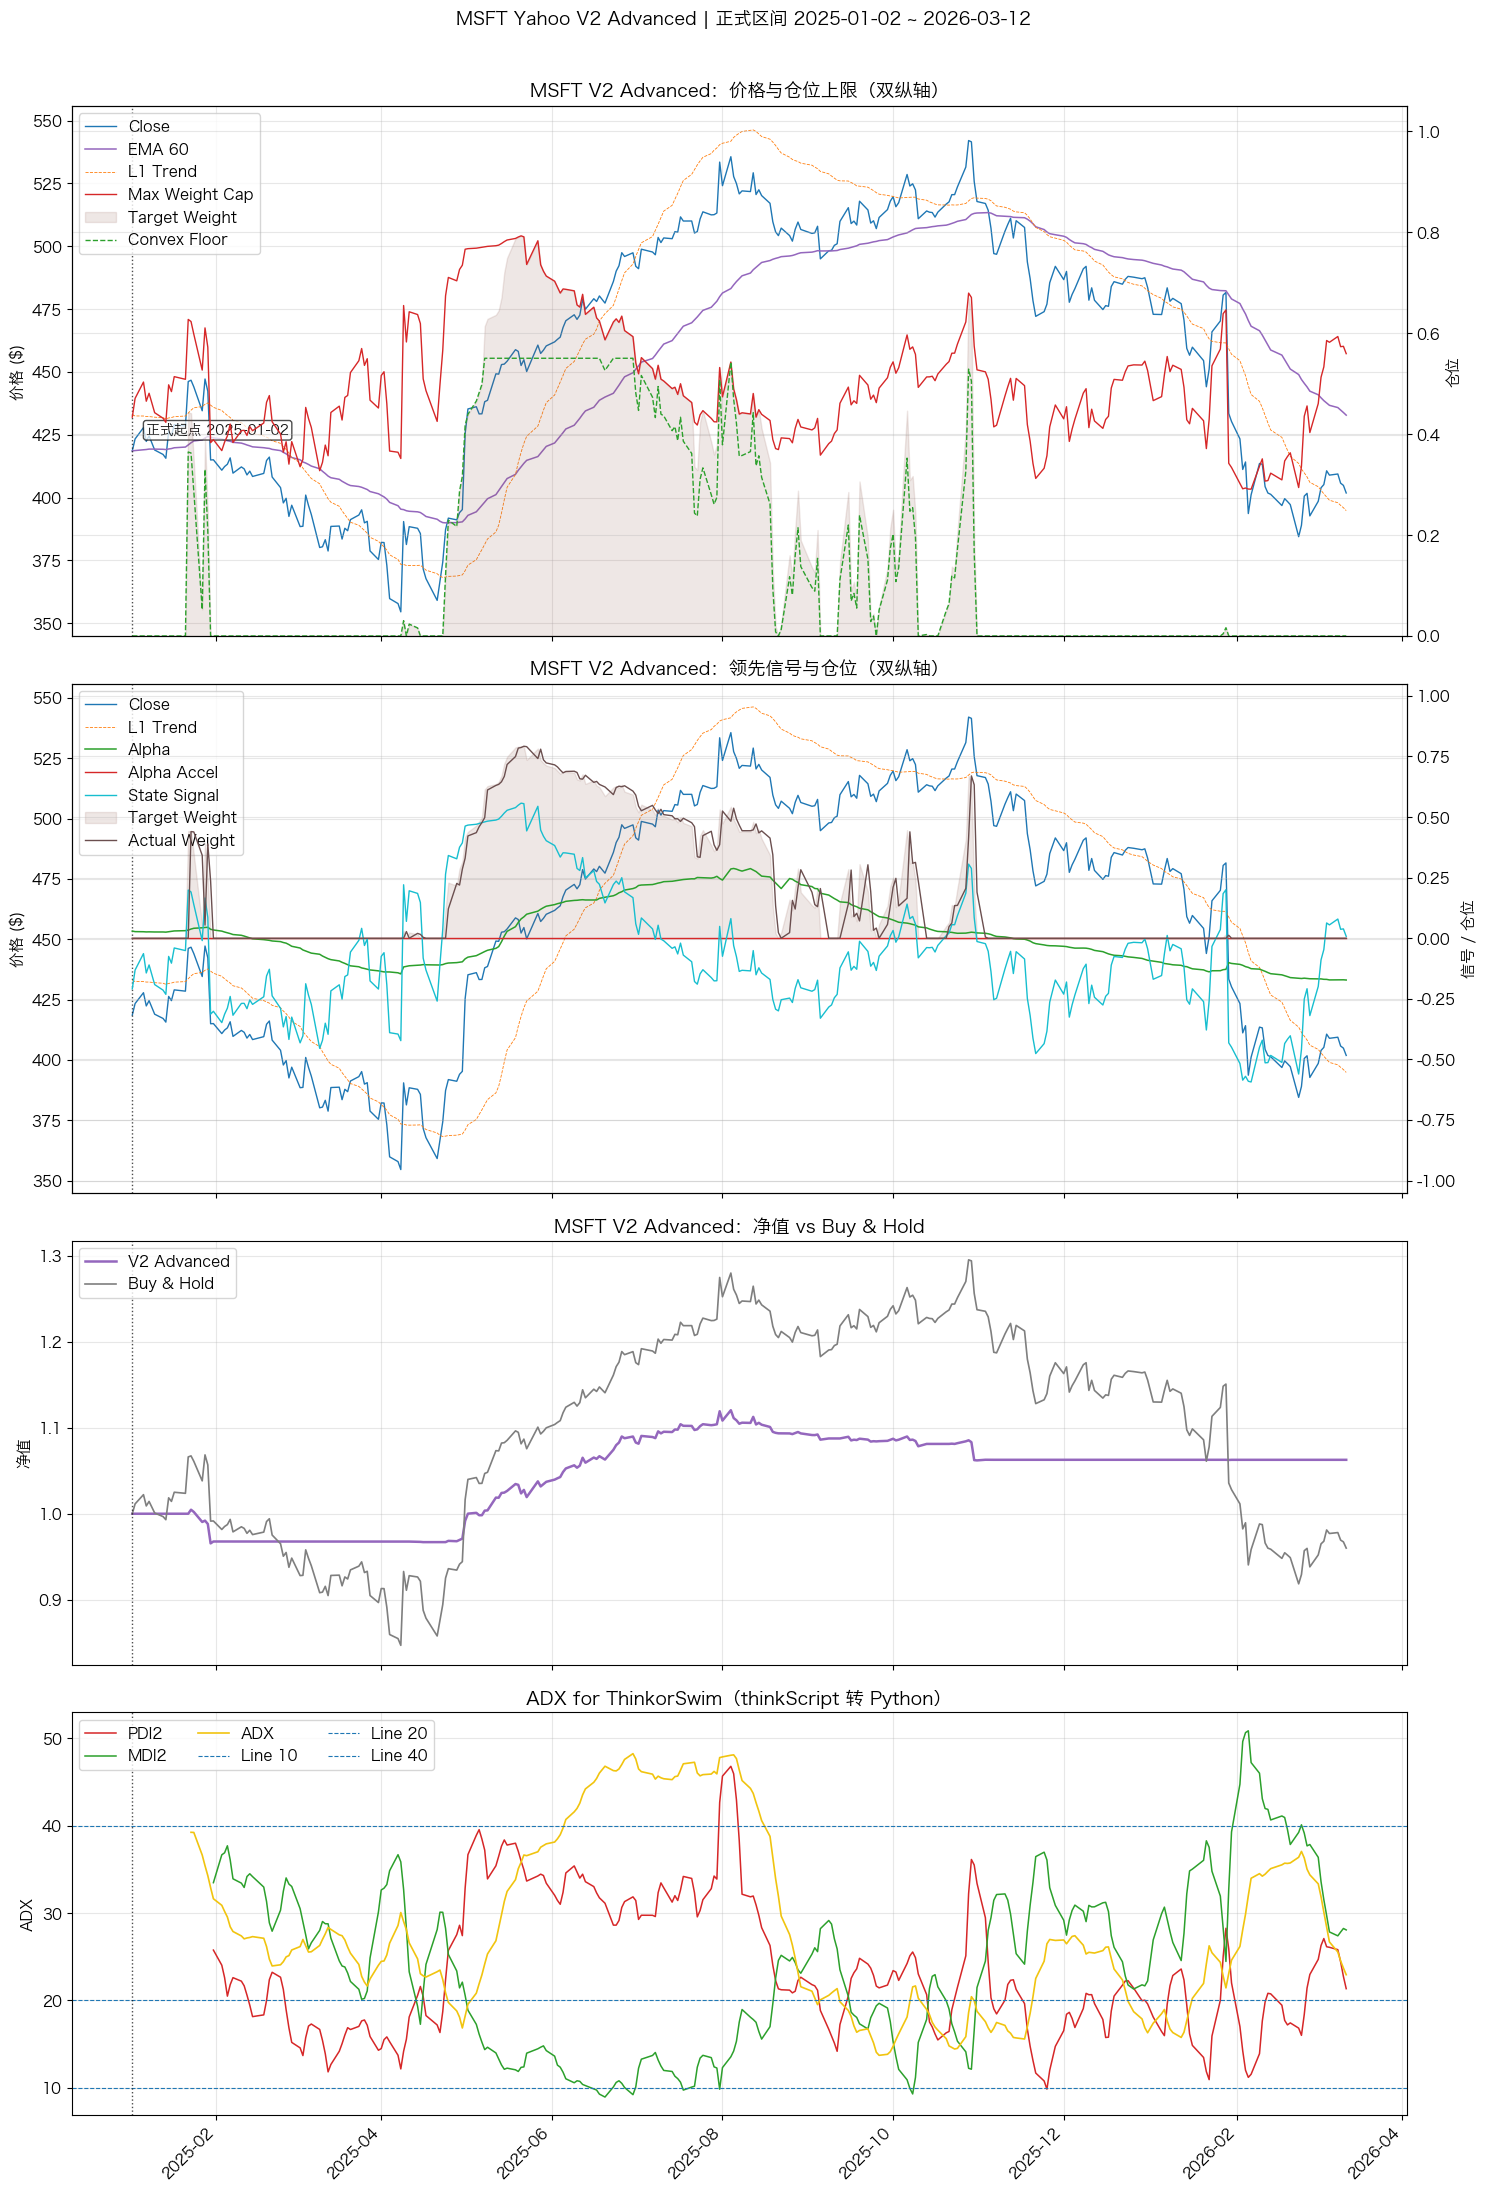

In [9]:
required_globals = [
    'fetch_daily_history',
    'l1_trend_filter',
    'solve_long_only_weight',
    'infer_convex_state_weights',
    'compute_convex_diagnostics',
    'solve_single_asset_weight_v2',
    'calc_performance_metrics',
    'validate_formal_coverage',
    'compute_tos_adx',
    'SYMBOL',
    'DATA_START',
    'DATA_END',
    'FETCH_START',
    'DEFAULT_WARMUP_CALENDAR_DAYS',
    'STRICT_WARMUP',
    'STRICT_END_DATE_COVERAGE',
    'TREND_WINDOW',
    'TREND_LAMBDA',
    'VOL_WINDOW',
    'SIGNAL_SPAN',
    'INITIAL_CASH',
    'COMMISSION_RATE',
    'SLIPPAGE_PCT',
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f'当前单元依赖前面的基础单元，缺少: {missing_globals}')

if 'YahooPandasData' not in globals():
    class YahooPandasData(bt.feeds.PandasData):
        params = (
            ('datetime', None),
            ('open', 'open'),
            ('high', 'high'),
            ('low', 'low'),
            ('close', 'close'),
            ('volume', 'volume'),
            ('openinterest', None),
        )

def run_single_asset_v2(symbol, profile='advanced'):
    required_warmup_bars = max(TREND_WINDOW, VOL_WINDOW + 1, SIGNAL_SPAN * 2 + 2)
    local_history, local_fetch_start, available_bars = ensure_history_with_warmup(symbol, required_warmup_bars, strict=STRICT_WARMUP)
    local_bt_df = local_history[['open', 'high', 'low', 'close', 'volume']].copy()
    local_bt_df.index = pd.to_datetime(local_bt_df.index).tz_localize(None)
    local_start_ts = pd.Timestamp(DATA_START)
    local_end_ts = pd.Timestamp(DATA_END)

    class SingleAssetV2Strategy(bt.Strategy):
        params = dict(
            trend_window=TREND_WINDOW,
            trend_lambda=TREND_LAMBDA,
            vol_window=VOL_WINDOW,
            signal_span=SIGNAL_SPAN,
            profile=profile,
            backtest_start=local_start_ts,
            backtest_end=local_end_ts,
        )

        def __init__(self):
            self.order = None
            self.previous_target_weight = 0.0
            self.records = []

        def notify_order(self, order):
            if order.status in [order.Completed, order.Canceled, order.Margin, order.Rejected]:
                self.order = None

        def next(self):
            current_dt = bt.num2date(self.datas[0].datetime[0]).replace(tzinfo=None)
            current_close = float(self.data.close[0])
            portfolio_value = float(self.broker.getvalue())
            position_value = float(self.position.size * current_close)
            actual_weight = position_value / portfolio_value if portfolio_value > 0 else 0.0
            min_bars = max(self.p.trend_window, self.p.vol_window + 1, self.p.signal_span * 2 + 2)
            in_formal_window = self.p.backtest_start <= pd.Timestamp(current_dt) <= self.p.backtest_end

            if len(self) < min_bars:
                self.records.append({
                    'datetime': current_dt,
                    'close': current_close,
                    'trend': np.nan,
                    'alpha': 0.0,
                    'alpha_accel': 0.0,
                    'bull_score': np.nan,
                    'range_score': np.nan,
                    'bear_score': np.nan,
                    'state_signal': 0.0,
                    'raw_composite_alpha': np.nan,
                    'composite_alpha': np.nan,
                    'max_weight_cap': np.nan,
                    'target_weight': actual_weight,
                    'floor_weight': 0.0,
                    'actual_weight': actual_weight,
                    'portfolio_value': portfolio_value,
                    'in_formal_window': in_formal_window,
                })
                return

            hist_close = np.array(self.data.close.get(size=self.p.trend_window), dtype=float)
            vol_close = np.array(self.data.close.get(size=self.p.vol_window + 1), dtype=float)
            hist_returns = pd.Series(vol_close).pct_change().dropna()
            sigma = hist_returns.std() * np.sqrt(252)
            diag = compute_convex_diagnostics(hist_close, lam=self.p.trend_lambda, signal_span=self.p.signal_span)
            allocation = solve_single_asset_weight_v2(
                alpha=diag['alpha'],
                alpha_accel=diag['alpha_accel'],
                trend_gap=diag['trend_gap'],
                sigma=sigma,
                previous_weight=self.previous_target_weight,
                bull_score=diag['bull_score'],
                range_score=diag['range_score'],
                bear_score=diag['bear_score'],
                profile=self.p.profile,
            )
            target_weight = allocation['target_weight']
            if not in_formal_window:
                target_weight = 0.0

            if self.order is None:
                self.order = self.order_target_percent(target=target_weight)

            self.previous_target_weight = target_weight
            self.records.append({
                'datetime': current_dt,
                'close': current_close,
                'trend': diag['trend_last'],
                'alpha': diag['alpha'],
                'alpha_accel': diag['alpha_accel'],
                'bull_score': diag['bull_score'],
                'range_score': diag['range_score'],
                'bear_score': diag['bear_score'],
                'state_signal': diag['state_signal'],
                'raw_composite_alpha': allocation['raw_composite_alpha'],
                'composite_alpha': allocation['composite_alpha'],
                'target_weight': target_weight,
                'floor_weight': allocation['floor_weight'],
                'desired_floor': allocation['desired_floor'],
                'max_weight_cap': allocation['max_weight_cap'],
                'actual_weight': actual_weight,
                'portfolio_value': portfolio_value,
                'in_formal_window': in_formal_window,
            })

    local_cerebro = bt.Cerebro(stdstats=False)
    local_cerebro.broker.setcash(INITIAL_CASH)
    local_cerebro.broker.setcommission(commission=COMMISSION_RATE)
    local_cerebro.broker.set_slippage_perc(SLIPPAGE_PCT)
    local_cerebro.adddata(YahooPandasData(dataname=local_bt_df), name=symbol)
    local_cerebro.addstrategy(SingleAssetV2Strategy)
    local_results = local_cerebro.run()
    local_strategy = local_results[0]

    local_full_df = pd.DataFrame(local_strategy.records).set_index('datetime')
    local_full_df.index = pd.to_datetime(local_full_df.index)
    local_df = local_full_df.loc[(local_full_df.index >= local_start_ts) & (local_full_df.index <= local_end_ts)].copy()
    coverage_ok, coverage_msg, actual_last_date = validate_formal_coverage(
        local_df,
        DATA_END,
        strict=STRICT_END_DATE_COVERAGE,
        label='V2 Advanced 正式回测区间'
    )
    local_benchmark = local_df['close'] / float(local_df['close'].iloc[0])
    perf_df, perf_table = calc_performance_metrics(
        portfolio_value=local_df['portfolio_value'],
        benchmark_curve=local_benchmark,
        strategy_label='V2 Advanced',
        benchmark_label='Buy & Hold',
    )
    local_df['equity_curve'] = perf_df['equity_curve']
    local_df['buy_hold_curve'] = perf_df['benchmark_curve']
    return {
        'history': local_history,
        'fetch_start': local_fetch_start,
        'warmup_bars': available_bars,
        'result_df': local_df,
        'comparison': perf_table,
        'coverage_ok': coverage_ok,
        'coverage_msg': coverage_msg,
        'formal_start': local_df.index[0],
        'formal_end': local_df.index[-1],
        'actual_last_date': actual_last_date,
    }

advanced_result = run_single_asset_v2(SYMBOL, profile='advanced')
advanced_df = advanced_result['result_df']
advanced_df['ema60'] = advanced_df['close'].ewm(span=60, adjust=False).mean()
formal_history = advanced_result['history'].loc[(advanced_result['history'].index >= advanced_result['formal_start']) & (advanced_result['history'].index <= advanced_result['formal_end'])].copy()
adx_df = compute_tos_adx(formal_history[['high', 'low', 'close']], length=14)
advanced_df = advanced_df.join(adx_df, how='left')
formal_start_label = f'正式起点 {advanced_result["formal_start"].date()}'

print('=== Yahoo V2 Advanced 单标的结果 ===')
print(f'当前标的: {SYMBOL} | 预热样本数: {advanced_result["warmup_bars"]} | 起点: {advanced_result["fetch_start"].date()}')
print(f'正式回测区间: {advanced_result["formal_start"].date()} ~ {advanced_result["formal_end"].date()}')
print(f'结束日覆盖状态: {advanced_result["coverage_msg"]}')
display(advanced_result['comparison'].style.format('{:.2%}', subset=['总收益', '年化收益', '年化波动', '最大回撤']).format('{:.2f}', subset=['Sharpe']))
display(advanced_df[['close', 'ema60', 'trend', 'alpha', 'alpha_accel', 'bull_score', 'range_score', 'bear_score', 'state_signal', 'raw_composite_alpha', 'composite_alpha', 'max_weight_cap', 'floor_weight', 'target_weight', 'actual_weight', 'ADX', 'PDI2', 'MDI2', 'equity_curve', 'buy_hold_curve']].tail(12))

fig, axes = plt.subplots(4, 1, figsize=(15, 22), sharex=True, gridspec_kw={'height_ratios': [1.25, 1.2, 1.0, 0.95]})

axes[0].plot(advanced_df.index, advanced_df['close'], label='Close', color='#1f77b4', linewidth=1.0)
axes[0].plot(advanced_df.index, advanced_df['ema60'], label='EMA 60', color='#9467bd', linewidth=1.1)
axes[0].plot(advanced_df.index, advanced_df['trend'], label='L1 Trend', color='#ff7f0e', linewidth=0.6, linestyle='--')
axes[0].set_title(f'{SYMBOL} V2 Advanced：价格与仓位上限（双纵轴）')
axes[0].set_ylabel('价格 ($)')
price_ax2 = axes[0].twinx()
price_ax2.plot(advanced_df.index, advanced_df['max_weight_cap'], label='Max Weight Cap', color='#d62728', linewidth=1.0)
price_ax2.fill_between(advanced_df.index, 0, advanced_df['target_weight'], color='#8c564b', alpha=0.14, label='Target Weight')
price_ax2.plot(advanced_df.index, advanced_df['floor_weight'], color='#2ca02c', linewidth=1.0, linestyle='--', label='Convex Floor')
price_ax2.set_ylabel('仓位')
price_ax2.set_ylim(0, 1.05)
lines0, labels0 = axes[0].get_legend_handles_labels()
lines0b, labels0b = price_ax2.get_legend_handles_labels()
axes[0].legend(lines0 + lines0b, labels0 + labels0b, loc='upper left')

axes[1].plot(advanced_df.index, advanced_df['close'], label='Close', color='#1f77b4', linewidth=1.0)
axes[1].plot(advanced_df.index, advanced_df['trend'], label='L1 Trend', color='#ff7f0e', linewidth=0.6, linestyle='--')
axes[1].set_title(f'{SYMBOL} V2 Advanced：领先信号与仓位（双纵轴）')
axes[1].set_ylabel('价格 ($)')
signal_ax2 = axes[1].twinx()
signal_ax2.plot(advanced_df.index, advanced_df['alpha'], label='Alpha', color='#2ca02c', linewidth=1.1)
signal_ax2.plot(advanced_df.index, advanced_df['alpha_accel'], label='Alpha Accel', color='#d62728', linewidth=1.0)
signal_ax2.plot(advanced_df.index, advanced_df['state_signal'], label='State Signal', color='#17becf', linewidth=1.0)
signal_ax2.fill_between(advanced_df.index, 0, advanced_df['target_weight'], color='#8c564b', alpha=0.14, label='Target Weight')
signal_ax2.plot(advanced_df.index, advanced_df['actual_weight'], color='#6b4f4f', linewidth=1.0, label='Actual Weight')
signal_ax2.set_ylabel('信号 / 仓位')
signal_ax2.set_ylim(-1.05, 1.05)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = signal_ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

axes[2].plot(advanced_df.index, advanced_df['equity_curve'], label='V2 Advanced', color='#9467bd', linewidth=1.8)
axes[2].plot(advanced_df.index, advanced_df['buy_hold_curve'], label='Buy & Hold', color='#7f7f7f', linewidth=1.2)
axes[2].set_title(f'{SYMBOL} V2 Advanced：净值 vs Buy & Hold')
axes[2].set_ylabel('净值')
axes[2].legend(loc='upper left')

axes[3].plot(advanced_df.index, advanced_df['PDI2'], label='PDI2', color='#d62728', linewidth=1.1)
axes[3].plot(advanced_df.index, advanced_df['MDI2'], label='MDI2', color='#2ca02c', linewidth=1.1)
axes[3].plot(advanced_df.index, advanced_df['ADX'], label='ADX', color='#f1c40f', linewidth=1.2)
axes[3].axhline(10, color='#1f77b4', linestyle='--', linewidth=0.8, label='Line 10')
axes[3].axhline(20, color='#1f77b4', linestyle='--', linewidth=0.8, label='Line 20')
axes[3].axhline(40, color='#1f77b4', linestyle='--', linewidth=0.8, label='Line 40')
buy_points = advanced_df['BuySignal'].dropna()
if not buy_points.empty:
    axes[3].scatter(buy_points.index, buy_points.values, marker='^', color='#17becf', s=46, label='Buy Signal', zorder=4)
axes[3].set_title('ADX for ThinkorSwim（thinkScript 转 Python）')
axes[3].set_ylabel('ADX')
axes[3].legend(loc='upper left', ncol=3)

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=45, ha='right')

for ax_obj in axes:
    ax_obj.axvline(advanced_result['formal_start'], color='#111111', linestyle=':', linewidth=1.0, alpha=0.75)

axes[0].annotate(
    formal_start_label,
    xy=(advanced_result['formal_start'], advanced_df['close'].iloc[0]),
    xytext=(10, 12),
    textcoords='offset points',
    fontsize=10,
    color='#111111',
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#111111', alpha=0.75)
)

fig.suptitle(
    f'{SYMBOL} Yahoo V2 Advanced | 正式区间 {advanced_result["formal_start"].date()} ~ {advanced_result["formal_end"].date()}',
    y=0.995,
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()